In [7]:
import numpy as np
import matplotlib.pyplot as plt

Total curves generated: 10000
Total filtered curves: 9931


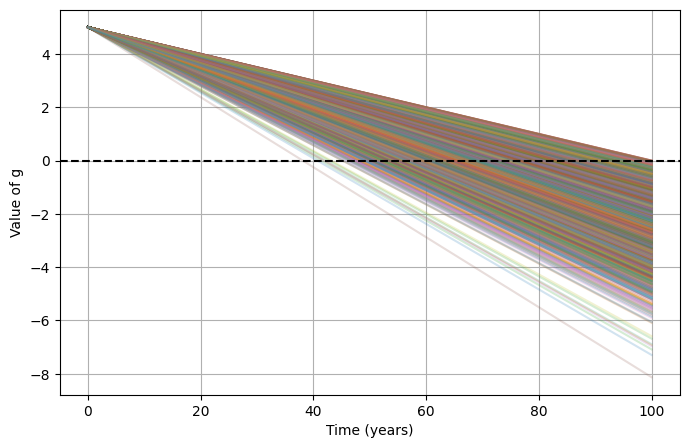

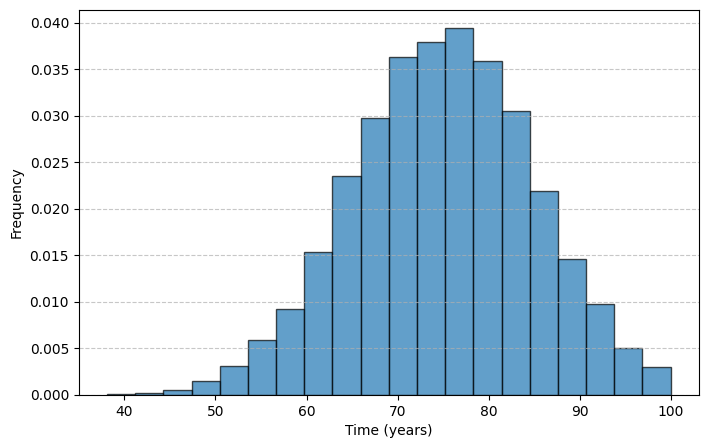

In [8]:
# Parameters
time = np.arange(0, 101, 1)  # years from 0 to 100
initial_value = 5.0
n_samples = 10000

# Dataset generation
dataset = []
for _ in range(n_samples):
    decay_time = np.random.normal(75, 10, 1)[0]
    g = initial_value * (1 - time / decay_time)
    dataset.append(g)

dataset = np.array(dataset)

# Filtering: only curves that cross g=0
filtered_curves = []
crossing_times = []

for g in dataset:
    if np.any(g <= 0):
        for i in range(1, len(g)):
            if g[i-1] > 0 and g[i] <= 0:
                # Interpolation for exact crossing time
                t1, t2 = time[i-1], time[i]
                g1, g2 = g[i-1], g[i]
                cross_time = t1 - g1 * (t2 - t1) / (g2 - g1)
                crossing_times.append(cross_time)
                filtered_curves.append(g)
                break

filtered_curves = np.array(filtered_curves)

# Save to use in another script
np.save("time.npy", time)
np.save("curves.npy", filtered_curves)

# Info prints
print(f"Total curves generated: {len(dataset)}")
print(f"Total filtered curves: {len(filtered_curves)}")

# Plot filtered curves
plt.figure(figsize=(8, 5))
for g in filtered_curves:
    plt.plot(time, g, alpha=0.2)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.grid()
plt.show()

# Histogram of crossing times (as probability density)
plt.figure(figsize=(8, 5))
plt.hist(crossing_times, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Time (years)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Total curves in dataset: 9931
Total curves crossing vertical line at year 35.0: 9931


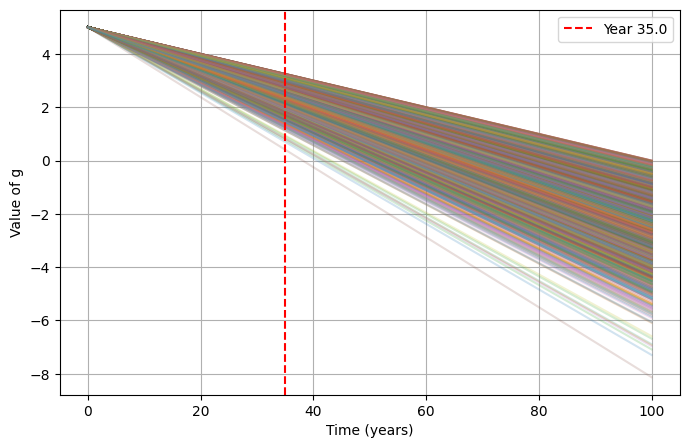

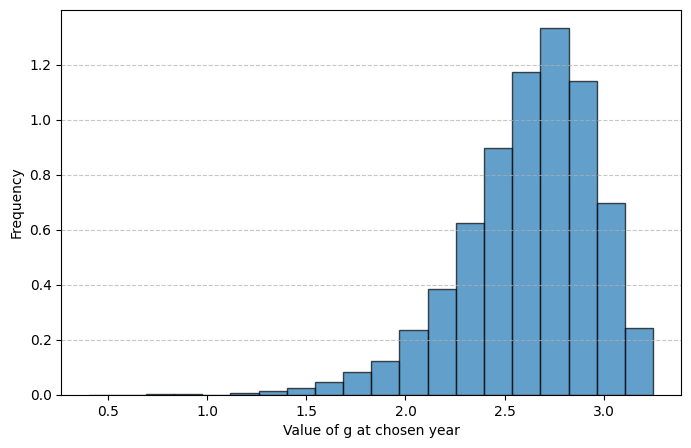

In [9]:
# Load saved data
time = np.load("time.npy")
curves = np.load("curves.npy")

# User input
chosen_year = float(input("Enter the year (0 to 100): "))
if chosen_year < 0 or chosen_year > 100:
    raise ValueError("The year must be between 0 and 100.")

# Save the chosen year for use in Code 3
np.save("chosen_year.npy", chosen_year)

# List to store g values at the chosen year
g_values_at_year = []

for g in curves:
    if chosen_year in time:
        g_val = g[int(chosen_year)]
    else:
        g_val = np.interp(chosen_year, time, g)
    g_values_at_year.append(g_val)

# Counts
total_curves = len(curves)
total_crossing = len(g_values_at_year)
print(f"Total curves in dataset: {total_curves}")
print(f"Total curves crossing vertical line at year {chosen_year}: {total_crossing}")

# Plot curves with vertical line
plt.figure(figsize=(8, 5))
for g in curves:
    plt.plot(time, g, alpha=0.2)
plt.axvline(x=chosen_year, color='r', linestyle='--', label=f"Year {chosen_year}")
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.legend()
plt.grid()
plt.show()

# Histogram of g values at intersection
plt.figure(figsize=(8, 5))
plt.hist(g_values_at_year, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Value of g at chosen year')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


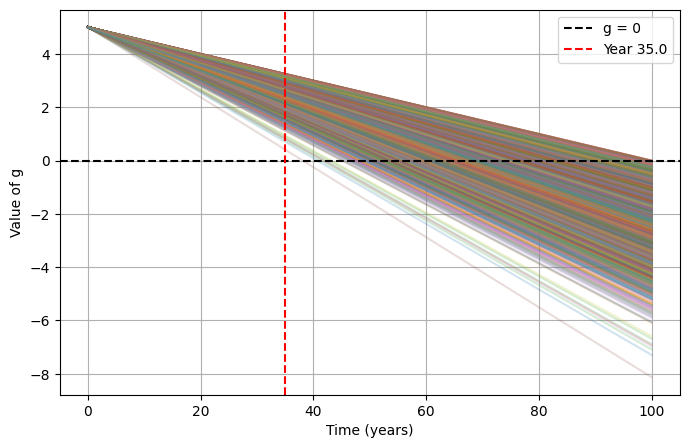

In [10]:
# Load saved data
time = np.load("time.npy")
curves = np.load("curves.npy")
chosen_year = np.load("chosen_year.npy")  # year defined in Code 2

# Combined plot
plt.figure(figsize=(8, 5))
for g in curves:
    plt.plot(time, g, alpha=0.2)

# Add the two lines
plt.axhline(0, color='k', linestyle='--', label="g = 0")
plt.axvline(x=chosen_year, color='r', linestyle='--', label=f"Year {chosen_year}")

# Graph configuration
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.legend()
plt.grid()
plt.show()


Total curves considered: 9931
Crossings after year 35.0: 9931


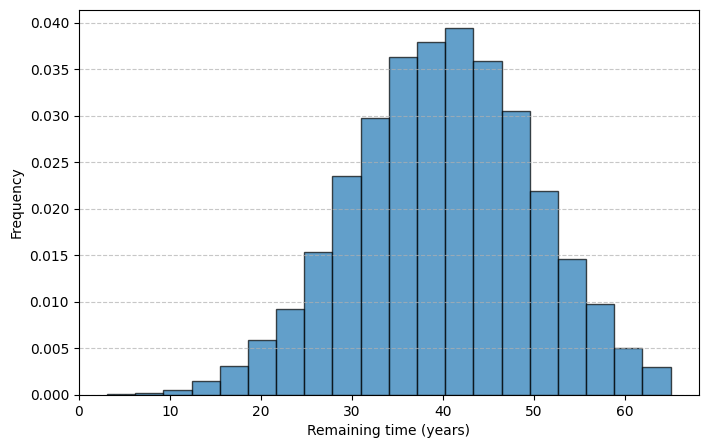

In [13]:
# Load data
time = np.load("time.npy")
curves = np.load("curves.npy")
chosen_year = np.load("chosen_year.npy")

remaining_times = []

for g in curves:
    # Check if curve crosses g=0
    if np.any(g <= 0):
        for i in range(1, len(g)):
            if g[i-1] > 0 and g[i] <= 0:
                # Interpolation for exact crossing time
                t1, t2 = time[i-1], time[i]
                g1, g2 = g[i-1], g[i]
                crossing_time = t1 - g1 * (t2 - t1) / (g2 - g1)
                
                # Only consider crossings after the chosen year
                if crossing_time > chosen_year:
                    remaining_times.append(crossing_time - chosen_year)
                break

# Basic statistics
print(f"Total curves considered: {len(curves)}")
print(f"Crossings after year {chosen_year}: {len(remaining_times)}")

# Histogram of remaining times
plt.figure(figsize=(8,5))
plt.hist(remaining_times, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel(f"Remaining time (years)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


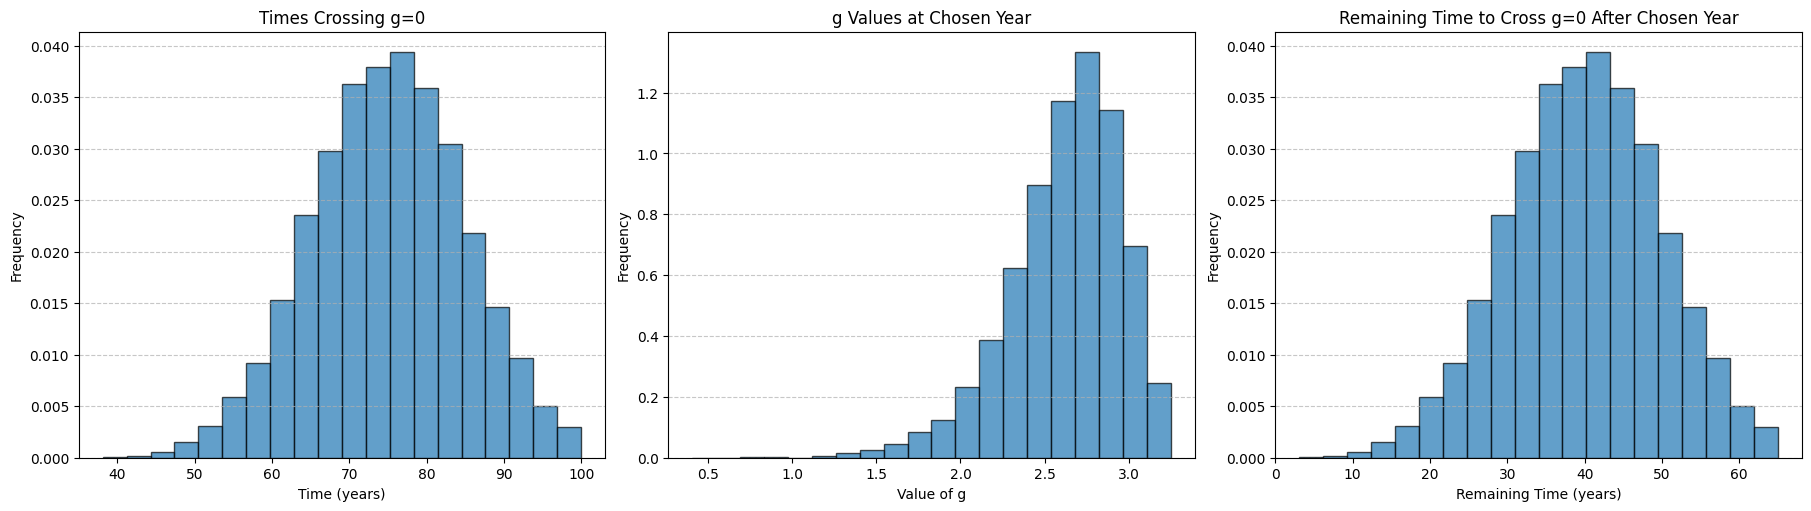

In [12]:

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Histogram 1: Times curves cross g=0 (original)
axs[0].hist(crossing_times, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[0].set_title('Times Crossing g=0')
axs[0].set_xlabel('Time (years)')
axs[0].set_ylabel('Frequency')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram 2: g values at the chosen year
axs[1].hist(g_values_at_year, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[1].set_title('g Values at Chosen Year')
axs[1].set_xlabel('Value of g')
axs[1].set_ylabel('Frequency')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram 3: Remaining time after chosen year until crossing g=0
axs[2].hist(remaining_times, bins=20, edgecolor='black', alpha=0.7, density=True)
axs[2].set_title('Remaining Time to Cross g=0 After Chosen Year')
axs[2].set_xlabel('Remaining Time (years)')
axs[2].set_ylabel('Frequency')
axs[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



In [ ]:
# Cria o dataset completo
# Filtra para tirar as g's que não chegam a zero
# Salva o ponto de tempo onde g cruza zero
# distribuição via histograma do tempo de cruzamento
# cria uma função que pega esse dataset o usu´rio escolhe um tempo qualquer t_inspec e retorna o rul ai plota o histograma do rul
# cria o histograma para o tempo escolhido. No caso histograma de g
